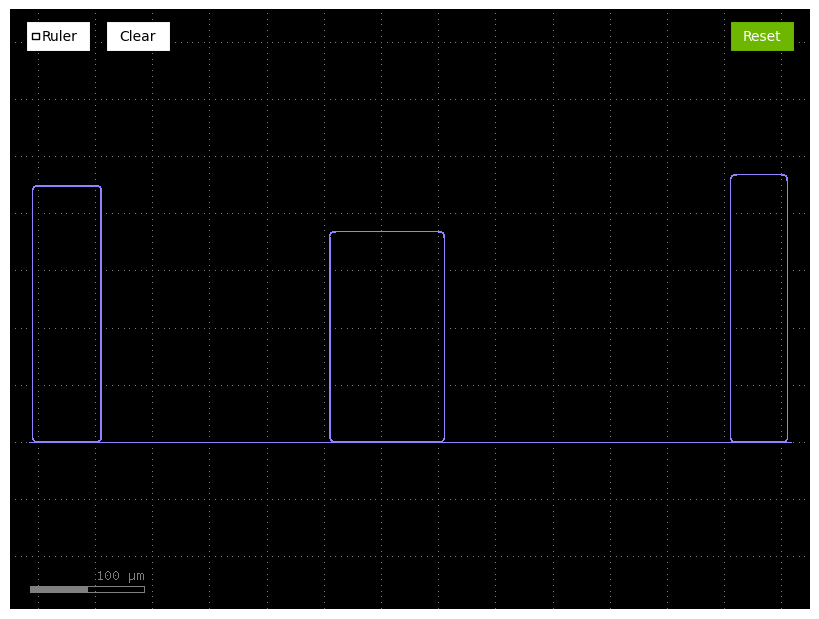

In [ ]:
import gdsfactory as gf
from typing import List
import numpy as np
import cspdk.si220.cband
from axiomatic.pic_helpers import plot_circuit

cspdk.si220.cband.activate_pdk()

pdk = gf.get_active_pdk()

def ring_resonator(coupling_length: float, target_fsr: float, center_wvl: float) -> gf.Component:
    bend_radius = 5  # microns
    n_eff = 2.38
    n_g = 4.3

    cavity_length_target_fsr = center_wvl**2 / (n_g * target_fsr * 1e-3)
    m = round(n_eff * cavity_length_target_fsr / center_wvl)
    ring_length_target = m * center_wvl / n_eff
    length_arc = 2 * np.pi * bend_radius

    c = gf.Component()
    length_x = coupling_length
    length_y = (ring_length_target - length_arc - 2 * length_x) / 2

    ring = c << pdk.get_component(
        'ring_single',
        radius=bend_radius,
        gap=0.2,
        length_x=length_x,
        length_y=length_y
    )
    ring.name = "ring"
    ring.move((0.0, 0.0))
    c.add_port("in0", port=ring.ports["o1"])
    c.add_port("out0", port=ring.ports["o2"])
    return c

def multi_ring_resonator(num_rings: int, spacing: float, coupling_length: List[float], target_fsr: List[float], center_wvl: List[float]) -> gf.Component:
    c = gf.Component()

    rings = []
    for i in range(num_rings):
        ring = c << ring_resonator(coupling_length[i], target_fsr[i], center_wvl[i])
        ring.move((i*spacing, 0))
        rings.append(ring)
    
    for i in range(len(rings)-1):
        gf.routing.route_single(
                component=c,
                port1=rings[i].ports["out0"],
                port2=rings[i+1].ports["in0"],
                bend="bend_euler",
                cross_section="strip"
            )


    # Add bus input/output ports
    c.add_port("bus_in", port=rings[0].ports["in0"])
    c.add_port("bus_out", port=rings[0].ports["out0"])

    return c



# Example usage and plot
if __name__ == "__main__":
    c = multi_ring_resonator(
        num_rings=3,
        spacing=150,
        coupling_length=[50, 90, 40],
        target_fsr=[1, 1, 1],
        center_wvl=[1.55, 1.55, 1.55]
    )
    plot_circuit(c)
